In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import statsmodels.api as sm
import pickle as pkl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

<div dir="rtl">
    
##    להלן בעיה: בחברה לייצור מתכות רוצים לבדוק את השפעת מס שעות הדרכת בטיחות בחודש וכמות השקעה כספית בבטיחות המכונות על מספר תאונות שקורות בחודש. 

<div dir="rtl">  ננסה לעשות מודל רגרסיה:

$$\hat{Y} = \hat{b_0} + \hat{b_1}*X_1 + \hat{b_2}*X_2 $$

<div dir="rtl"> כאשר $X_1$  מציין שעות הדרכה ו $X_2$ מציין השקעה כספית בבטיחות המכונות.

In [2]:
data = pkl.load( open('../pkl/data_lesson_3.pkl', 'rb'))
data = data.loc[:, ['guidence', 'invsetment', 'accidents', 'Factory', 'intercept']]
data.head()

,guidence,invsetment,accidents,Factory,intercept
0,0.0,0.00,347,Ariel,1
1,0.0,1.25,346,Ariel,1
2,0.0,2.50,342,Ariel,1
3,0.0,3.75,334,Haifa,1
4,0.0,5.00,341,Ariel,1


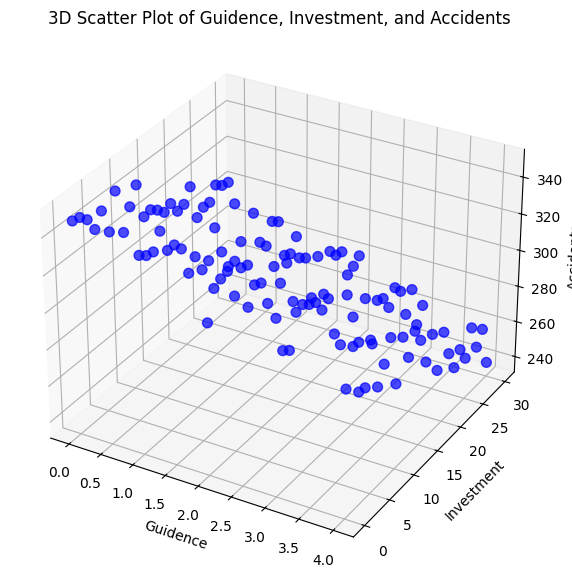

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

# Assuming 'data' is a pandas DataFrame
x = data['guidence']
y = data['invsetment']
z = data['accidents']

# Create figure and 3D axes
fig = plt.figure(figsize=(14,7))
ax = fig.add_subplot(111, projection='3d')

# Plot scatter
ax.scatter(x, y, z, c='blue', marker='o', s=50, alpha=0.7)

# Set axis labels
ax.set_xlabel("Guidence")
ax.set_ylabel("Investment")
ax.set_zlabel("Accidents")

# Set a title
ax.set_title("3D Scatter Plot of Guidence, Investment, and Accidents")

plt.show()

In [7]:
# Create a linear regression model
model = sm.OLS(data['accidents'], data[['intercept', 'guidence', 'invsetment']])
# Fit the model
results = model.fit()
# Print summary statistics, including p-values for each coefficient
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     368.1
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           2.08e-52
Time:                        09:59:09   Log-Likelihood:                -449.12
No. Observations:                 125   AIC:                             904.2
Df Residuals:                     122   BIC:                             912.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    348.0794      1.912    182.026      0.0

## Statistical significance

<div dir="rtl">
    
###   מובהקות הסטטיסטית היא מושג בסטטיסטיקה שעוזר לחוקרים לקבוע האם תוצאות של ניסוי, מחקר או ניתוח סבירותיות להיות משמעותיות או האם הן יכולות לקרות באופן אקראי. זהו מרכיב חשוב בבדיקת היפותזה ונמצא בשימוש כדי לקבוע החלטות מבוססות על נתונים.
    
### הנה הרכיבים המרכזיים והשלבים המעוררים כרוך בהערכת החשיבות הסטטיסטית:

<div dir="rtl">
    
###   השערת אלטרנטיבה (Ha): השערת אלטרנטיבה היא ההצהרה שחוקרים רוצים לתמוך או להוכיח. היא מרמזת על פעולה או קשר משמעותי בנתונים. בדוגמה של ניסוי תרופות, השערת האלטרנטיבה עשויהה לציין שהתרופה החדשה יעילה יותר מהפלסבו.


<div dir="rtl">
    
###    רמת מובהקות (α): רמת המובהקות, שנקראת גם אלפא (α), מייצגת את הסיכוי לביצוע שגיאת סוג I. שגיאת סוג I. רמות מובהקות הנפוצות הן 0.05 (5%) ו־0.01 (1%).

###      שגיאה זו מציינת מקרה בו לא דוחים את השערת ה-0 למרות שהיינו צריכים.

<div dir="rtl">
  
###     ערך p_value: ערך p_value הוא מדידה של הראייה נגד השערת האפס. הוא מציין את הסיכוי לקבלת התוצאות שנראות (או תוצאות יותר קיצוניות) אם השערת האפס היא נכונה. ערך p_value קטן (בדרך כלל פחות מאלפא) מרמז על ראייה חזקה נגד השערת האפס.


<div dir="rtl"> 
    
### להלן כיצד התהליך פועל:


<div dir="rtl">
    
###   החוקרים אוספים נתונים ומבצעים ניתוח סטטיסטי.
    
### הם מחשבים מובהקות סטטיסטית בהתבסס על הנתונים.
    
### מחשבים את ערך p_value, שמציין את הסיכוי לראות את הנתונים שנראים אם השערת האפס היא נכונה.
    
### אם ערך p_value קטן מאלפא או זהה לו, החוקרים דוחים את השערת האפס לטובת השערת האלטרנטיבה

<div dir="rtl">
    
###     גם כשאנחנו עושים מודל רגרסיה אנחנו עושים מבחן סטטיסטי. המבחן בעצם מתייחס לפרמטרים של המודל: $b_0$, $b_1$, $b_2$ .

<div dir="rtl">
   
###    פורמלית המבחן עבור כל פרמטר נראה כך:

$$H_0: b_0 = 0, H_1: b_0 \neq 0$$
$$H_0: b_1 = 0, H_1: b_1 \neq 0$$
$$H_0: b_2 = 0, H_1: b_2 \neq 0$$


<div dir="rtl">
      
    
###    נרצה לבדוק האם כל משתנה הוא מובהק סטטיסטית ואז נוכל להכניסו למודל. מקובל לבדוק ברמת מובהקות של 0.05.  נבדוק את התוצאה בפלט של המודל בעמודה $P >|t|$.
    
<div dir="rtl">
    
### לפי הפלט כולם קטנים מ 0.05. למעשה כולם שואפים ל-0 מה שמצביע על תוצאות מאד מובהקות.
    
###   אם אחד הפרמטרים לא נכנס למודל אז נוציא את המשתנה ונבנה מודל חדש.
    
### כיצד נעשה חיזוי?

In [7]:
data['preds'] = results.predict(data.loc[:, ['intercept', 'guidence', 'invsetment']])

In [8]:
results.predict(np.array([[1,20,10]]))

array([139.16246154])

In [9]:
data.loc[data['guidence']==1,:].head(10)

,guidence,invsetment,accidents,Factory,intercept,preds
25,1.0,0.00,339,Ariel,1,338.571385
26,1.0,1.25,336,Ariel,1,336.226769
27,1.0,2.50,335,Ariel,1,333.882154
28,1.0,3.75,343,Jerusalem,1,331.537538
29,1.0,5.00,330,Ariel,1,329.192923
30,1.0,6.25,330,Ariel,1,326.848308
31,1.0,7.50,325,Ariel,1,324.503692
32,1.0,8.75,309,Haifa,1,322.159077
33,1.0,10.00,315,Ariel,1,319.814462
34,1.0,11.25,305,Haifa,1,317.469846


In [10]:
def linear_surface_eq(guidence, invsetment):
    return 348.0794 -9.5080*guidence -1.8757*invsetment


<div dir="rtl"> נציג ויזאולית את הנתונים על גבי המישור הליניארי שלמדנו. 

In [11]:
data['guidence'].shape

(125,)

In [9]:
X

array([[0., 0., 0., ..., 4., 4., 4.],
       [0., 0., 0., ..., 4., 4., 4.],
       [0., 0., 0., ..., 4., 4., 4.],
       ...,
       [0., 0., 0., ..., 4., 4., 4.],
       [0., 0., 0., ..., 4., 4., 4.],
       [0., 0., 0., ..., 4., 4., 4.]])

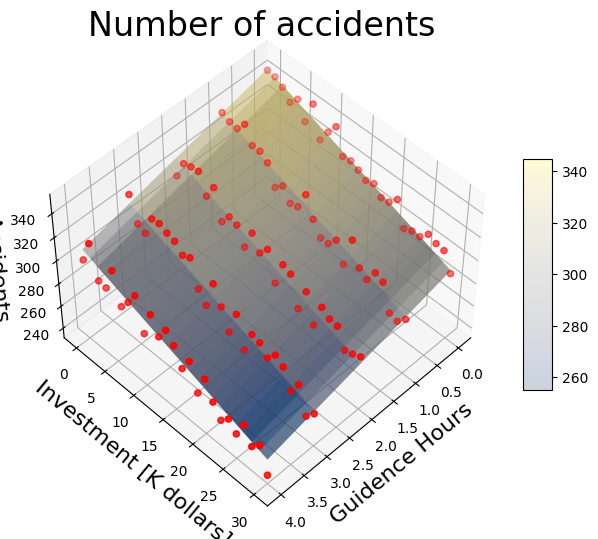

In [11]:
# 
X, Y = np.meshgrid(data['guidence'], data['invsetment'])
Z = linear_surface_eq(X, Y)

fig = plt.figure(figsize = (8,6))
ax = plt.axes(projection='3d')

surf1 = ax.plot_surface(X, Y, Z, cmap = plt.cm.cividis, alpha = 0.2)
ax.scatter(data['guidence'] , data['invsetment'], data['accidents'] , c='r', marker='o')
# Set axes label
ax.set_xlabel('Guidence Hours',fontsize = 16)
ax.set_ylabel('Investment [K dollars]',fontsize = 16)
ax.set_zlabel('Accidents',fontsize = 16)
plt.title('Number of accidents' ,fontsize = 24)
fig.colorbar(surf1, shrink=0.5, aspect=8)
ax.view_init(elev=50., azim=45)
plt.show()

<div dir="rtl">

###    מה זה meshgrid?

### זוהי פונקצייה שלוקחת שני וקטורים והופכת אותם למטריצות כך שהן פורסות מרחב דו ממדי. למשל: 

In [13]:
a = np.array([1,2,3])
b = np.array([4,5,6])
A, B = np.meshgrid(a,b)
A, B

(array([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]]),
 array([[4, 4, 4],
        [5, 5, 5],
        [6, 6, 6]]))

<div dir="rtl"> 

###    ניתן גם להציג את המשוואה בדו מימד באופן הבא:

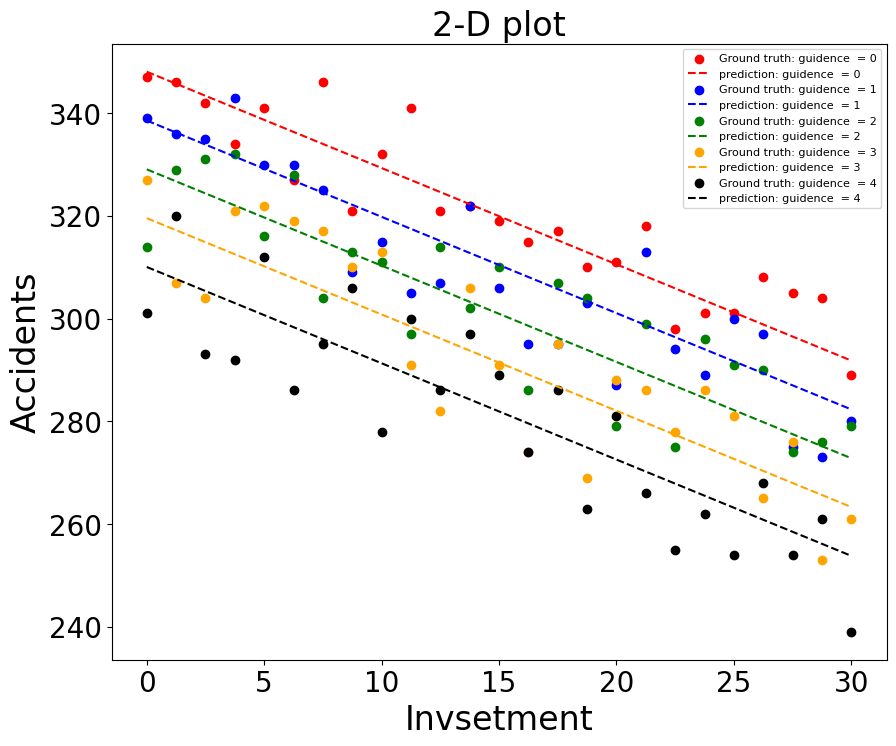

In [14]:
colors = ['red', 'blue', 'green', 'orange', 'black']
plt.figure(figsize=(10,8))
plt.title('2-D plot' ,fontsize = 24)
for guidence in [0,1,2,3,4]:
    plt.scatter(data.loc[data['guidence']==guidence,'invsetment'], data.loc[data['guidence']==guidence,'accidents'], label  = 'Ground truth: guidence  = '+str(guidence), color = colors[guidence] )
    plt.plot(data.loc[data['guidence']==guidence,'invsetment'], data.loc[data['guidence']==guidence,'preds'], label  = 'prediction: guidence  = '+str(guidence) , linestyle='dashed', color = colors[guidence])
    plt.xlabel('Invsetment', fontsize = 24)
    plt.ylabel('Accidents', fontsize = 24)
plt.legend(fontsize=8)
plt.show()

## Dummy variables

<div dir="rtl">
    
##     משתני דמה: לעיתים יש לנו משתנים שהם קטגוריאלים וייתכן שהם ישפיעו על המודל. למשל בדוגמא שלנו ייתכן שגם מיקום המפעל ישפיע על כמות תאונות. הבעיה היא שמודל רגרסיה מצפה למשתנים עם ערכים מספריים. ננסה להתגבר על האתגר הזה.

<div dir="rtl">
    
###    בדוגמא יש לנו 3 מיקומים שונים, אריאל, חיפה וירושלים. במקרה של 3 קטגוריות מוסיפים שני משתני דמה (הכלל הוא תמיד אחד פחות מסה"כ מספר הקטגוריות). המשתנה הראשון הוא משתנה בינארי שמציין האם הנתון מגיע מאריאל או לא נסמן ב$d_1$, והמשתנה השני מצביע על האם הנתון מגיע מחיפה או לא נסמן ב$d_2$. זה מצוין על ידי 0 ו-1, 0 אם לא, 1 אם כן. אם הערכים של שני משתני הדמה הם 0 משמעות הדבר שהנתון מגיע מירושלים. מודל הרגרסיה נראה כך:

## $$ \hat{Y} = \hat{b_0} + \hat{b_1}*X_1 +\hat{b_2} *X_2 + \hat{d_1} * D_1 +\hat{d_2}* D_2 $$

In [12]:
# One hot encoding

dummy_variables = pd.get_dummies(data['Factory']).astype(int)

dummy_variables

,Ariel,Haifa,Jerusalem
0,1,0,0
1,1,0,0
2,1,0,0
3,0,1,0
4,1,0,0
...,...,...,...
120,1,0,0
121,0,0,1
122,1,0,0
123,0,0,1


In [13]:
# Concatenate dummy variables with the original DataFrame and drop the original column
data = pd.concat([data, dummy_variables], axis=1)

data.head(10)

,guidence,invsetment,accidents,Factory,intercept,Ariel,Haifa,Jerusalem
0,0.0,0.00,347,Ariel,1,1,0,0
1,0.0,1.25,346,Ariel,1,1,0,0
2,0.0,2.50,342,Ariel,1,1,0,0
3,0.0,3.75,334,Haifa,1,0,1,0
4,0.0,5.00,341,Ariel,1,1,0,0
5,0.0,6.25,327,Haifa,1,0,1,0
6,0.0,7.50,346,Jerusalem,1,0,0,1
7,0.0,8.75,321,Haifa,1,0,1,0
8,0.0,10.00,332,Ariel,1,1,0,0
9,0.0,11.25,341,Jerusalem,1,0,0,1


In [36]:
# Create a linear regression model
model = sm.OLS(data['accidents'], data.loc[:, ['intercept', 'guidence', 'invsetment', 'Ariel','Haifa']])
# Fit the model
results = model.fit()
# Print summary statistics, including p-values for each coefficient
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     3975.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):          1.80e-126
Time:                        10:41:51   Log-Likelihood:                -265.17
No. Observations:                 125   AIC:                             540.3
Df Residuals:                     120   BIC:                             554.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    360.5409      0.550    655.267      0.0

In [17]:
print(data.dtypes)

guidence      float64
invsetment    float64
accidents       int32
Factory        object
intercept       int64
preds         float64
Ariel           int32
Haifa           int32
Jerusalem       int32
dtype: object


In [17]:
data['preds'] = results.predict(data.loc[:, ['intercept', 'guidence', 'invsetment', 'Ariel','Haifa']])

<div dir="rtl">


### ננסה לחזות כמות תאונות ממוצע כאשר הערך של הדרכה הוא 2 והשקעה הוא 5 עבור חיפה וירושלים

In [18]:
results.predict(np.array([[1,2,5,0,1]])), results.predict(np.array([[1,2,5,0,0]])) 

(array([308.92511636]), array([330.618627]))

In [20]:
308.92511636 - 330.618627 

-21.69351064

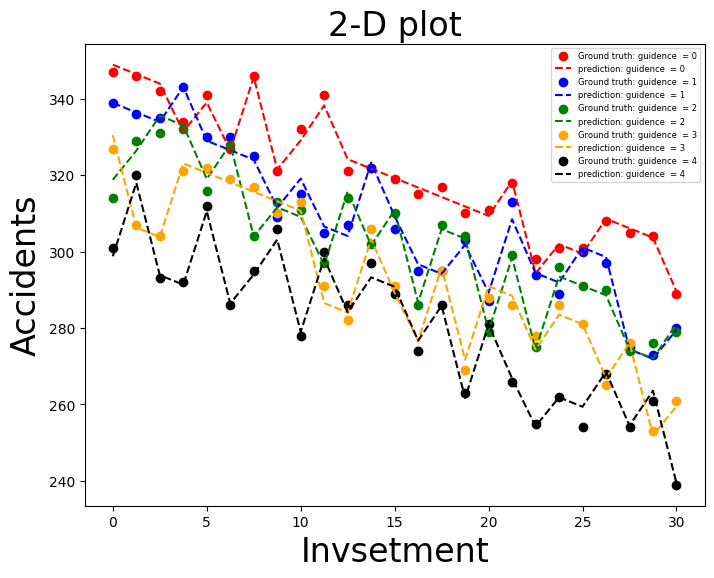

In [21]:
colors = ['red', 'blue', 'green', 'orange', 'black']
plt.figure(figsize=(8,6))
plt.title('2-D plot' ,fontsize = 24)
for guidence in [0,1,2,3,4]:
    plt.scatter(data.loc[data['guidence']==guidence,'invsetment'], data.loc[data['guidence']==guidence,'accidents'], label  = 'Ground truth: guidence  = '+str(guidence), color = colors[guidence] )
    plt.plot(data.loc[data['guidence']==guidence,'invsetment'], data.loc[data['guidence']==guidence,'preds'], label  = 'prediction: guidence  = '+str(guidence) , linestyle='dashed', color = colors[guidence])
    plt.xlabel('Invsetment', fontsize = 24)
    plt.ylabel('Accidents', fontsize = 24)
plt.legend(fontsize=6)
plt.show()

<div dir="rtl">  ננסה עכשיו לעשות תחזית עבור ערך בודד: כמה תאונות צפויות בירושלים אם אין הדרכות בכלל ומשקיעים 5000 דולר בבטיחות?

In [22]:
results.predict(np.array([1, 0, 5, 0,0]))

array([350.64891994])

<div dir="rtl">  ה-1 בהתחלה מציין את העובדה שיש חותך במשוואה, 0 מציין שאין שעות הדרכה, 5 מציין את ההשקעה בבטיחות ושני האפסים בסוף מציינים שזה לא באריאל ולא בחיפה - דהיינו בירושלים.


## איך אני יודע איזה משתנה הכי משפיע על החיזוי?

### דבר ראשון אפשר להסתכל על המקדמים של כולם.

### הבעיה היא שמשתנים שונים יכולים להיות ביחדיות שונות ולא היהי הגיוני להשוות בינהם.

### למשל שעות הדרכה וכסף השקעה בעשרות אלפי דולריםלא ניתנים להשוואה

### לכן מה שעושים איזשהו נרמול מסוים.

### נחשב מקדם מנורמל באופן הבא: 

### $$ beta_i = \beta_i \frac{s_{X_i}}{s_{Y}} $$



### כאשר $s_{X_i}$ זה הסטית תקן של הנתונים של המשתנה ה-i ואילו $s_{Y}$ זה הנתונים של המשתנה המוסבר 

### בעצם אני לראות כמה סטיות תקן שח Y משתנות כשינוי של סטיית תקן של המשתנה המסביר i

### נחשב את זה:

In [46]:
sX

guidence      1.419905
invsetment    9.050151
Ariel         0.481932
Haifa         0.442573
dtype: float64

In [47]:
data.loc[:, ['guidence','invsetment','Ariel','Haifa']]

,guidence,invsetment,Ariel,Haifa
0,0.0,0.00,1,0
1,0.0,1.25,1,0
2,0.0,2.50,1,0
3,0.0,3.75,0,1
4,0.0,5.00,1,0
...,...,...,...,...
120,4.0,25.00,1,0
121,4.0,26.25,0,0
122,4.0,27.50,1,0
123,4.0,28.75,0,0


In [48]:
data['accidents']

0      347
1      346
2      342
3      334
4      341
      ... 
120    254
121    268
122    254
123    261
124    239
Name: accidents, Length: 125, dtype: int32

In [45]:
# Extract raw coefficients (excluding intercept)
betas_raw = results.params[1:]

# Compute standard deviations
sY = data['accidents'].std()
sX = data.loc[:, ['guidence','invsetment','Ariel','Haifa']].std()

# Compute standardized coefficients
betas_std = betas_raw * sX / sY

betas_std.values

array([-0.60726481, -0.76459226, -0.23893575, -0.40999308])

In [43]:
# Combine into a readable table
std_beta_table = pd.DataFrame({
    'Variable': [ 'guidence', 'invsetment', 'Ariel','Haifa'],
    'Unstandardized Beta': betas_raw.values,
    'Standardized Beta': betas_std.values
})


std_beta_table

,Variable,Unstandardized Beta,Standardized Beta
0,guidence,-10.015146,-0.607265
1,invsetment,-1.978392,-0.764592
2,Ariel,-11.610050,-0.238936
3,Haifa,-21.693511,-0.409993


## Multicollinearity 

<div dir="rtl">


##     לא נרצה להכניס את כל משתני הדמה למודל כי אז תהיה לנו תלות בין המשתנים. דבר כזה יכול לגרום לשונות גדולה בתחזית.

In [23]:
data_correlated = data
data_correlated['inverstment_shekels'] = data_correlated['invsetment']*4

In [24]:
data_correlated.head()

,guidence,invsetment,accidents,Factory,intercept,Ariel,Haifa,Jerusalem,preds,inverstment_shekels
0,0.0,0.00,347,Ariel,1,1,0,0,348.930831,0.0
1,0.0,1.25,346,Ariel,1,1,0,0,346.457841,5.0
2,0.0,2.50,342,Ariel,1,1,0,0,343.984851,10.0
3,0.0,3.75,334,Haifa,1,0,1,0,331.428400,15.0
4,0.0,5.00,341,Ariel,1,1,0,0,339.038870,20.0


In [53]:
# Create a linear regression model
model = sm.OLS(data_correlated['accidents'], data_correlated.loc[:, ['intercept', 'guidence', 'invsetment', 'inverstment_shekels', 'Ariel','Haifa', 'Jerusalem']])
# Fit the model
results = model.fit()
# Print summary statistics, including p-values for each coefficient
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     3975.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):          1.80e-126
Time:                        12:17:22   Log-Likelihood:                -265.17
No. Observations:                 125   AIC:                             540.3
Df Residuals:                     120   BIC:                             554.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept             262.0798    

In [57]:
# Create a linear regression model
model = sm.OLS(data_correlated['accidents'], data_correlated.loc[:, ['intercept',  'invsetment', 'inverstment_shekels']])
# Fit the model
results = model.fit()
# Print summary statistics, including p-values for each coefficient
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     136.2
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           1.21e-21
Time:                        12:24:38   Log-Likelihood:                -524.46
No. Observations:                 125   AIC:                             1053.
Df Residuals:                     123   BIC:                             1059.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept             329.0634    

In [58]:
results.params[1:]

invsetment            -0.110335
inverstment_shekels   -0.441339
dtype: float64

In [59]:
# Extract raw coefficients (excluding intercept)
betas_raw = results.params[1:]

# Compute standard deviations
sY = data_correlated['accidents'].std()
sX =  data_correlated.loc[:, [ 'invsetment', 'inverstment_shekels']].std()

# Compute standardized coefficients
betas_std = betas_raw * sX / sY

betas_std.values

# Combine into a readable table
std_beta_table = pd.DataFrame({
    'Variable': [ 'invsetment', 'inverstment_shekels'],
    'Unstandardized Beta': betas_raw.values,
    'Standardized Beta': betas_std.values
})


std_beta_table

,Variable,Unstandardized Beta,Standardized Beta
0,invsetment,-0.110335,-0.042641
1,inverstment_shekels,-0.441339,-0.682260


## $$ y_i = \beta_0 +\beta_1*shekels + \beta_2*dollars $$

## $$ y_i = \beta_0 +\beta_1*shekels + \beta_2*4*shekeles $$
## $$ y_i = \beta_0 +shekels(\beta_1 + \beta_2*4) $$


<div dir="rtl">

## קיבלנו ערכים מנורמלים שונים למרות שזה אותו משתנה בדיוק